# Youtube Analysis for Hantavirus

## How to Run the Notebook

This notebook is structured in stages. Run the sections in order to reproduce the YouTube analysis.

### 1. Data Collection (optional)

The first section uses the YouTube Data API to collect Hantavirus-related videos and comments from multiple search queries. The collected data is saved as:

`Data/hantavirus_youtube_data.json`

This section does not need to be re-run if the JSON file already exists.

### 2. Load Dataset and Data Exploration

The saved JSON file is loaded and converted into two DataFrames:

- `videos_df`: video metadata such as title, channel name, upload date, view count, like count and comment count
- `comments_df`: comment-level data such as comment text, author, publication date and like count

This section also checks the number of videos and comments collected, the distribution of comments across videos, and the publication date range of the videos.

### 3. Text Preprocessing

This section prepares YouTube comments for analysis by removing missing or empty comments, filtering English comments, lightly cleaning text for sentiment analysis, and tokenising text for keyword analysis.

A lightly cleaned full-comment version is kept for VADER sentiment analysis because VADER works better when sentence context is preserved.

### 4. Term Frequency and Bigram Analysis

This section identifies common words and word pairs in the video titles and comments. These results are used to understand the main discussion themes, such as cruise ships, COVID comparisons, human-to-human transmission, public health advice and expert commentary.

### 5. VADER Sentiment Analysis

This section applies VADER sentiment analysis to classify YouTube comments as positive, neutral or negative. It also visualises the overall sentiment distribution and compound sentiment scores.

### 6. Sentiment by Video Type

This section classifies videos into source types such as news media, medical/expert, political commentary and general/trending content. Sentiment results are then compared across these video types to examine whether public opinion differs depending on the source and framing of the video.

### 7. Export Final Datasets

The final section saves the cleaned and analysed datasets:

- `Data/youtube_videos_final_analysis.csv`
- `Data/youtube_comments_final_analysis.csv`

Intermediate CSV files are not required because the notebook can recreate them from the raw JSON file.

## 1. YouTube API Client
This function creates a connection to the YouTube Data API using an API key, allowing the program to retrieve video and comment data.

The data is collected using the YouTube Data API v3.  
A set of highly relevant videos was selected using keyword-based search.  
Comments were collected from these videos for later sentiment and text analysis.

In [1]:
!pip install google-api-python-client

In [ ]:
# from example given youtubeClient.py
# @author Hexu Chen, RMIT University, 2026
# @author Chenglong Ma, RMIT University, 2026

from googleapiclient.discovery import build

def youtubeClient():
    apiKey = "apikey" # this was my api key
    youtube = build('youtube', 'v3', developerKey=apiKey)
    return youtube

## Fetching Youtube Data
This section collects Hantavirus-related YouTube videos and comments using the YouTube Data API. Multiple search queries are used to capture news, public health, expert explanation and general outbreak discussion videos.

This section does not need to be re-run once the data has been saved. The collected dataset is saved as:

`Data/hantavirus_youtube_data.json`

In [6]:
import json
import os

In [ ]:
SEARCH_QUERIES = [
    "hantavirus outbreak news",
    "hantavirus cruise ship outbreak",
    "hantavirus cruise ship news",
    "hantavirus update",
    "hantavirus risk explained",
    "hantavirus symptoms transmission",
    "hantavirus expert explains",
    "hantavirus public health",
    "hantavirus 2026"
]

MAX_VIDEOS_PER_QUERY = 12
MAX_COMMENTS_PER_VIDEO = None
OUTPUT_FILE = "Data/hantavirus_youtube_data.json"

In [ ]:
def fetchYoutubeDataMultipleQueries(
    searchQueries,
    maxVideosPerQuery=12,
    maxCommentsPerVideo=None,
    outputFile="Data/hantavirus_youtube_data.json"
):
    """
    Fetch YouTube videos and comments for multiple search queries.

    The function:
    - searches videos for each query
    - removes duplicate videos across search queries using videoId
    - fetches video statistics
    - fetches all available top-level comments if maxCommentsPerVideo is None
    - saves the final dataset to a JSON file
    """

    client = youtubeClient()

    os.makedirs(os.path.dirname(outputFile), exist_ok=True)

    videoIds = []
    videoSnippets = {}
    videoSearchQueries = {}

    # Step 1: Search for videos across multiple queries
    for query in searchQueries:
        print(f"Searching for videos with query: '{query}'...")

        searchResponse = client.search().list(
            q=query,
            part="snippet",
            type="video",
            order="relevance",
            maxResults=min(maxVideosPerQuery, 50)
        ).execute()

        for item in searchResponse.get("items", []):
            videoId = item["id"]["videoId"]

            # Avoid duplicate videos across search queries
            if videoId not in videoSnippets:
                videoIds.append(videoId)
                videoSnippets[videoId] = item["snippet"]
                videoSearchQueries[videoId] = query

    print(f"\nTotal unique videos found: {len(videoIds)}")

    if len(videoIds) == 0:
        print("No videos found. Check API setup or search queries.")
        return

    # Step 2: Fetch video statistics
    print("\nFetching video statistics...")

    videoStats = {}

    # videos.list can handle up to 50 video IDs per request
    for i in range(0, len(videoIds), 50):
        batchIds = videoIds[i:i + 50]

        statsResponse = client.videos().list(
            id=",".join(batchIds),
            part="statistics"
        ).execute()

        for item in statsResponse.get("items", []):
            videoStats[item["id"]] = item.get("statistics", {})

    # Step 3: Fetch comments
    print("\nFetching comments...")

    videos = []

    for videoId in videoIds:
        snippet = videoSnippets[videoId]
        stats = videoStats.get(videoId, {})

        video = {
            "videoId": videoId,
            "title": snippet.get("title", ""),
            "description": snippet.get("description", ""),
            "channelTitle": snippet.get("channelTitle", ""),
            "channelId": snippet.get("channelId", ""),
            "publishedAt": snippet.get("publishedAt", ""),
            "searchQuery": videoSearchQueries.get(videoId, ""),
            "url": f"https://www.youtube.com/watch?v={videoId}",
            "viewCount": int(stats.get("viewCount", 0)),
            "likeCount": int(stats.get("likeCount", 0)),
            "commentCount": int(stats.get("commentCount", 0)),
            "comments": []
        }

        try:
            commentsFetched = 0
            nextPageToken = None

            while True:
                # If maxCommentsPerVideo is None, fetch all comments page by page
                if maxCommentsPerVideo is not None:
                    requestLimit = min(100, maxCommentsPerVideo - commentsFetched)

                    if requestLimit <= 0:
                        break
                else:
                    requestLimit = 100

                commentResponse = client.commentThreads().list(
                    videoId=videoId,
                    part="snippet",
                    maxResults=requestLimit,
                    pageToken=nextPageToken,
                    textFormat="plainText",
                    order="relevance"
                ).execute()

                for commentThread in commentResponse.get("items", []):
                    topComment = commentThread["snippet"]["topLevelComment"]["snippet"]

                    video["comments"].append({
                        "commentId": commentThread.get("id", ""),
                        "author": topComment.get("authorDisplayName", ""),
                        "text": topComment.get("textDisplay", ""),
                        "publishedAt": topComment.get("publishedAt", ""),
                        "likeCount": topComment.get("likeCount", 0)
                    })

                    commentsFetched += 1

                    if maxCommentsPerVideo is not None and commentsFetched >= maxCommentsPerVideo:
                        break

                if maxCommentsPerVideo is not None and commentsFetched >= maxCommentsPerVideo:
                    break

                nextPageToken = commentResponse.get("nextPageToken")

                if not nextPageToken:
                    break

            print(f"{video['title'][:70]}... -> {len(video['comments'])} comments")

        except Exception as e:
            print(f"{video['title'][:70]}... -> Comments disabled or error: {e}")

        videos.append(video)

    # Step 4: Save to JSON
    data = {
        "searchQueries": searchQueries,
        "maxVideosPerQuery": maxVideosPerQuery,
        "maxCommentsPerVideo": maxCommentsPerVideo,
        "videos": videos
    }

    with open(outputFile, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

    print(f"\nDone. Saved {len(videos)} unique videos to '{outputFile}'.")

In [ ]:
fetchYoutubeDataMultipleQueries(
    SEARCH_QUERIES,
    maxVideosPerQuery=MAX_VIDEOS_PER_QUERY,
    maxCommentsPerVideo=MAX_COMMENTS_PER_VIDEO,
    outputFile=OUTPUT_FILE
)

## Install Required Packages (if needed)
If runnning the notebook for the firstime, install the required libraries using:

In [1]:
!pip install pandas matplotlib nltk numpy scikit-learn langid wordcloud

## 2. Load Dataset and Initial Exploration

This section loads the saved YouTube dataset collected using the YouTube Data API. The raw JSON file contains video metadata and top-level comments for Hantavirus-related videos.

The data is converted into two DataFrames:

- `videos_df`: stores video-level information such as title, channel, upload date, views, likes and number of comments fetched.
- `comments_df`: stores comment-level information such as comment text, author, video ID, channel and publication date.

This makes the dataset easier to inspect, clean and analyse in later sections.

In [4]:
import json

# load saved youtube dataset
file_path = "Data/hantavirus_youtube_data.json"

with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

all_videos = data["videos"]

print("Total videos:", len(all_videos))
print("Search queries used:", len(data["searchQueries"]))

Total videos: 86
Search queries used: 9


In [7]:
import pandas as pd

# convert json structure into video and comment dataframes
video_rows = []
comment_rows = []

for video in all_videos:
    video_rows.append({
        "videoId": video["videoId"],
        "title": video["title"],
        "description": video["description"],
        "channelTitle": video["channelTitle"],
        "channelId": video["channelId"],
        "publishedAt": video["publishedAt"],
        "searchQuery": video["searchQuery"],
        "url": video["url"],
        "viewCount": video["viewCount"],
        "likeCount": video["likeCount"],
        "commentCount": video["commentCount"],
        "commentsFetched": len(video["comments"])
    })

    for comment in video["comments"]:
        comment_rows.append({
            "commentId": comment["commentId"],
            "videoId": video["videoId"],
            "title": video["title"],
            "channelTitle": video["channelTitle"],
            "searchQuery": video["searchQuery"],
            "commentAuthor": comment["author"],
            "commentText": comment["text"],
            "commentPublishedAt": comment["publishedAt"],
            "commentLikeCount": comment["likeCount"]
        })

videos_df = pd.DataFrame(video_rows)
comments_df = pd.DataFrame(comment_rows)

print("Videos dataframe:", videos_df.shape)
print("Comments dataframe:", comments_df.shape)

videos_df.head()

Videos dataframe: (86, 12)
Comments dataframe: (12042, 9)


,videoId,title,description,channelTitle,channelId,publishedAt,searchQuery,url,viewCount,likeCount,commentCount,commentsFetched
0,V07bI_iyMVA,Hantavirus cruise ship docks after seven weeks...,For more context and news coverage of the most...,NBC News,UCeY0bbntWzzVIaj2z3QigXg,2026-05-18T12:58:33Z,hantavirus outbreak news,https://www.youtube.com/watch?v=V07bI_iyMVA,1558,28,3,2
1,KpZN0OA0GNc,Hantavirus outbreak sparks global health conce...,The Hantavirus outbreak linked to the MV Hondi...,SABC News,UC8yH-uI81UUtEMDsowQyx1g,2026-05-17T16:21:21Z,hantavirus outbreak news,https://www.youtube.com/watch?v=KpZN0OA0GNc,8521,0,25,17
2,4URktweTzV4,Cruise ship linked to deadly hantavirus outbre...,The cruise ship linked to the deadly hantaviru...,The New Indian Express,UCQtVJ-76KjPds9evTODkq-A,2026-05-18T08:08:09Z,hantavirus outbreak news,https://www.youtube.com/watch?v=4URktweTzV4,4046,24,6,5
3,COt1faxmdO0,Hantavirus Outbreak | Learn English with the News,Today you'll learn English with a news article...,JForrest English,UCLNBasuHKOILIwewAetJO6g,2026-05-18T12:00:30Z,hantavirus outbreak news,https://www.youtube.com/watch?v=COt1faxmdO0,1587,275,28,25
4,4KWbgoo60D4,Last people aboard hantavirus ship finally dis...,The MV Hondius was carrying 25 crew members an...,Sky News,UCoMdktPbSTixAyNGwb-UYkQ,2026-05-18T12:01:14Z,hantavirus outbreak news,https://www.youtube.com/watch?v=4KWbgoo60D4,1643,17,1,1


In [8]:
# convert to df

video_rows = []
comment_rows = []

for video in all_videos:
    video_rows.append({
        "videoId": video["videoId"],
        "title": video["title"],
        "description": video["description"],
        "channelTitle": video["channelTitle"],
        "channelId": video["channelId"],
        "publishedAt": video["publishedAt"],
        "searchQuery": video["searchQuery"],
        "url": video["url"],
        "viewCount": video["viewCount"],
        "likeCount": video["likeCount"],
        "commentCount": video["commentCount"],
        "commentsFetched": len(video["comments"])
    })

    for comment in video["comments"]:
        comment_rows.append({
            "commentId": comment["commentId"],
            "videoId": video["videoId"],
            "title": video["title"],
            "channelTitle": video["channelTitle"],
            "searchQuery": video["searchQuery"],
            "commentAuthor": comment["author"],
            "commentText": comment["text"],
            "commentPublishedAt": comment["publishedAt"],
            "commentLikeCount": comment["likeCount"]
        })

videos_df = pd.DataFrame(video_rows)
comments_df = pd.DataFrame(comment_rows)

print("Videos dataframe:", videos_df.shape)
print("Comments dataframe:", comments_df.shape)

videos_df.head()

Videos dataframe: (86, 12)
Comments dataframe: (12042, 9)


,videoId,title,description,channelTitle,channelId,publishedAt,searchQuery,url,viewCount,likeCount,commentCount,commentsFetched
0,V07bI_iyMVA,Hantavirus cruise ship docks after seven weeks...,For more context and news coverage of the most...,NBC News,UCeY0bbntWzzVIaj2z3QigXg,2026-05-18T12:58:33Z,hantavirus outbreak news,https://www.youtube.com/watch?v=V07bI_iyMVA,1558,28,3,2
1,KpZN0OA0GNc,Hantavirus outbreak sparks global health conce...,The Hantavirus outbreak linked to the MV Hondi...,SABC News,UC8yH-uI81UUtEMDsowQyx1g,2026-05-17T16:21:21Z,hantavirus outbreak news,https://www.youtube.com/watch?v=KpZN0OA0GNc,8521,0,25,17
2,4URktweTzV4,Cruise ship linked to deadly hantavirus outbre...,The cruise ship linked to the deadly hantaviru...,The New Indian Express,UCQtVJ-76KjPds9evTODkq-A,2026-05-18T08:08:09Z,hantavirus outbreak news,https://www.youtube.com/watch?v=4URktweTzV4,4046,24,6,5
3,COt1faxmdO0,Hantavirus Outbreak | Learn English with the News,Today you'll learn English with a news article...,JForrest English,UCLNBasuHKOILIwewAetJO6g,2026-05-18T12:00:30Z,hantavirus outbreak news,https://www.youtube.com/watch?v=COt1faxmdO0,1587,275,28,25
4,4KWbgoo60D4,Last people aboard hantavirus ship finally dis...,The MV Hondius was carrying 25 crew members an...,Sky News,UCoMdktPbSTixAyNGwb-UYkQ,2026-05-18T12:01:14Z,hantavirus outbreak news,https://www.youtube.com/watch?v=4KWbgoo60D4,1643,17,1,1


### 2.1 Data Exploration

This section provides a basic overview of the YouTube dataset before text analysis. It checks the number of videos and comments collected, the distribution of comments per video, and the publication date range of the videos.

These checks help confirm whether the dataset is suitable for sentiment and topic analysis, and whether the comments are spread across enough videos to support comparison between different types of content.

In [9]:
# summarise number of comments fetched per video
total_comments = videos_df["commentsFetched"].sum()
min_comments = videos_df["commentsFetched"].min()
max_comments = videos_df["commentsFetched"].max()
avg_comments = videos_df["commentsFetched"].mean()

print("Total videos:", len(videos_df))
print("Total comments:", total_comments)
print("Minimum comments per video:", min_comments)
print("Maximum comments per video:", max_comments)
print("Average comments per video:", round(avg_comments, 2))

Total videos: 86
Total comments: 12042
Minimum comments per video: 0
Maximum comments per video: 1256
Average comments per video: 140.02


In [10]:
# show comment count for each video
for _, row in videos_df.iterrows():
    print(f"{row['title'][:70]}... -> {row['commentsFetched']} comments")

Hantavirus cruise ship docks after seven weeks at sea... -> 2 comments
Hantavirus outbreak sparks global health concerns and panic-driven spe... -> 17 comments
Cruise ship linked to deadly hantavirus outbreak to reach Netherlands ... -> 5 comments
Hantavirus Outbreak | Learn English with the News... -> 25 comments
Last people aboard hantavirus ship finally disembark... -> 1 comments
What are the origins of hantavirus? How the virus tied to the cruise s... -> 15 comments
Cruise ship hit by deadly hantavirus outbreak arrives in the Netherlan... -> 0 comments
🚢 🤢 Hantavirus Cruise Ship Outbreak: “Close Contact” - What It Really ... -> 70 comments
How Worried Should We Be About Hantavirus?... -> 43 comments
LIVE: Hantavirus Outbreak News: 3 Dead On Cruise Ship | WHO Chief Brie... -> 3 comments
Officials tracking at least 41 Americans after deadly hantavirus outbr... -> 143 comments
Why health officials expect hantavirus cases to continue rising... -> 336 comments
“No sign” of larger hantav

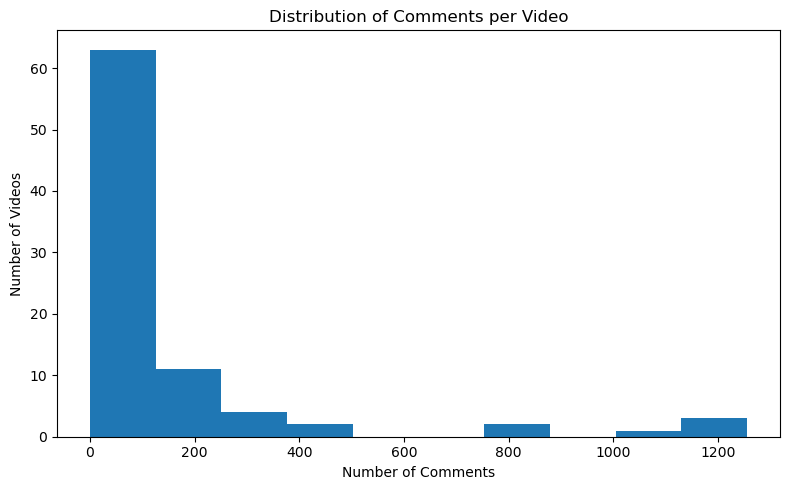

In [11]:
# histogram of comments per video
import matplotlib.pyplot as plt

# plot distribution of comments per video
plt.figure(figsize=(8, 5))
plt.hist(videos_df["commentsFetched"], bins=10)

plt.title("Distribution of Comments per Video")
plt.xlabel("Number of Comments")
plt.ylabel("Number of Videos")

plt.tight_layout()
plt.show()

In [12]:
from datetime import datetime
from collections import Counter

# convert published date to datetime
videos_df["publishedAt"] = pd.to_datetime(videos_df["publishedAt"])

# extract publication year
videos_df["year"] = videos_df["publishedAt"].dt.year

# show earliest and latest video year
print("Min year:", videos_df["year"].min())
print("Max year:", videos_df["year"].max())

# count videos per year
year_counts = videos_df["year"].value_counts().sort_index()

print("\nVideos per year:")
for year, count in year_counts.items():
    print(year, ":", count)

Min year: 2012
Max year: 2026

Videos per year:
2012 : 1
2022 : 1
2025 : 3
2026 : 81


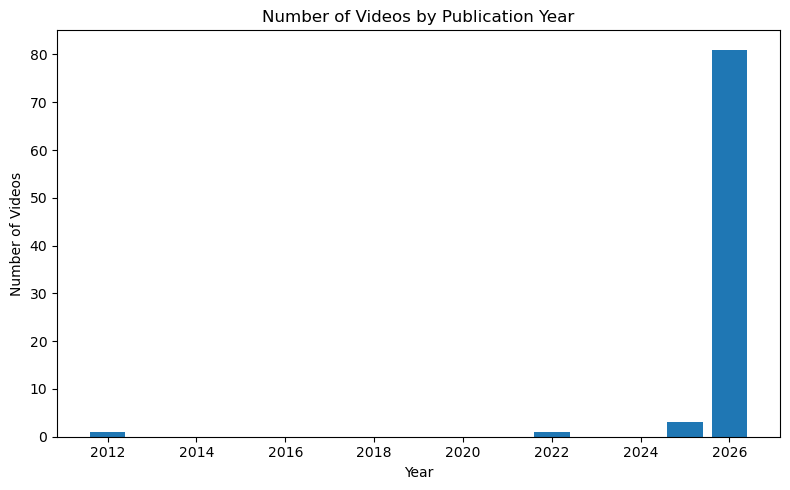

In [13]:
# plot number of videos by publication year
plt.figure(figsize=(8, 5))
plt.bar(year_counts.index, year_counts.values)

plt.title("Number of Videos by Publication Year")
plt.xlabel("Year")
plt.ylabel("Number of Videos")

plt.tight_layout()
plt.show()

/var/folders/rt/ntympq6n43582kgy0p0xxpc00000gn/T/ipykernel_77406/2910740495.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  videos_df["year_month"] = videos_df["publishedAt"].dt.to_period("M")


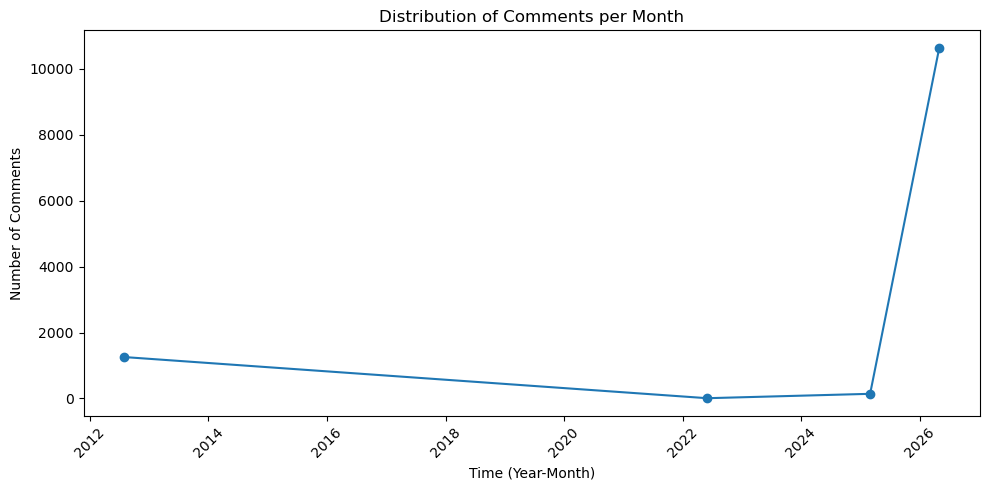

In [14]:
# create year-month column
videos_df["year_month"] = videos_df["publishedAt"].dt.to_period("M")

# aggregate fetched comments by month
comments_monthly = videos_df.groupby("year_month")["commentsFetched"].sum()

# convert period index to timestamp for plotting
comments_monthly.index = comments_monthly.index.to_timestamp()

# plot monthly comment trend
plt.figure(figsize=(10, 5))
plt.plot(comments_monthly.index, comments_monthly.values, marker="o")

plt.title("Distribution of Comments per Month")
plt.xlabel("Time (Year-Month)")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 3. Text Preprocessing

This section prepares the YouTube comments for text-based analysis. The preprocessing includes removing missing or empty comments, checking language, lowercasing text, tokenising comments, and removing stopwords, punctuation, digits and non-alphabetic tokens.

For VADER sentiment analysis, the notebook keeps a lightly cleaned version of each comment because VADER performs better on full sentences with context. The more heavily tokenised version is mainly used for keyword, term frequency and optional bigram analysis.

In [15]:
import string
import re
from collections import Counter

import nltk
import matplotlib.pyplot as plt
import langid

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/hazelkok/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [16]:
# remove missing and empty comments
comments_df = comments_df.dropna(subset=["commentText"]).copy()
comments_df["commentText"] = comments_df["commentText"].astype(str).str.strip()
comments_df = comments_df[comments_df["commentText"] != ""]

print("Total comments after removing empty comments:", len(comments_df))

Total comments after removing empty comments: 12042


In [17]:
# create a lightly cleaned version for vader sentiment analysis
def clean_for_sentiment(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

comments_df["cleanComment"] = comments_df["commentText"].apply(clean_for_sentiment)

comments_df[["commentText", "cleanComment"]].head()

,commentText,cleanComment
0,What happened to the CDC staff that were suppo...,What happened to the CDC staff that were suppo...
1,"Hopefully that virus, will cease from spreading.","Hopefully that virus, will cease from spreading."
2,This virus is a minor problem compared to the ...,This virus is a minor problem compared to the ...
3,I wonder what these criminals are up to now.,I wonder what these criminals are up to now.
4,When you stop reporting fake health concerns t...,When you stop reporting fake health concerns t...


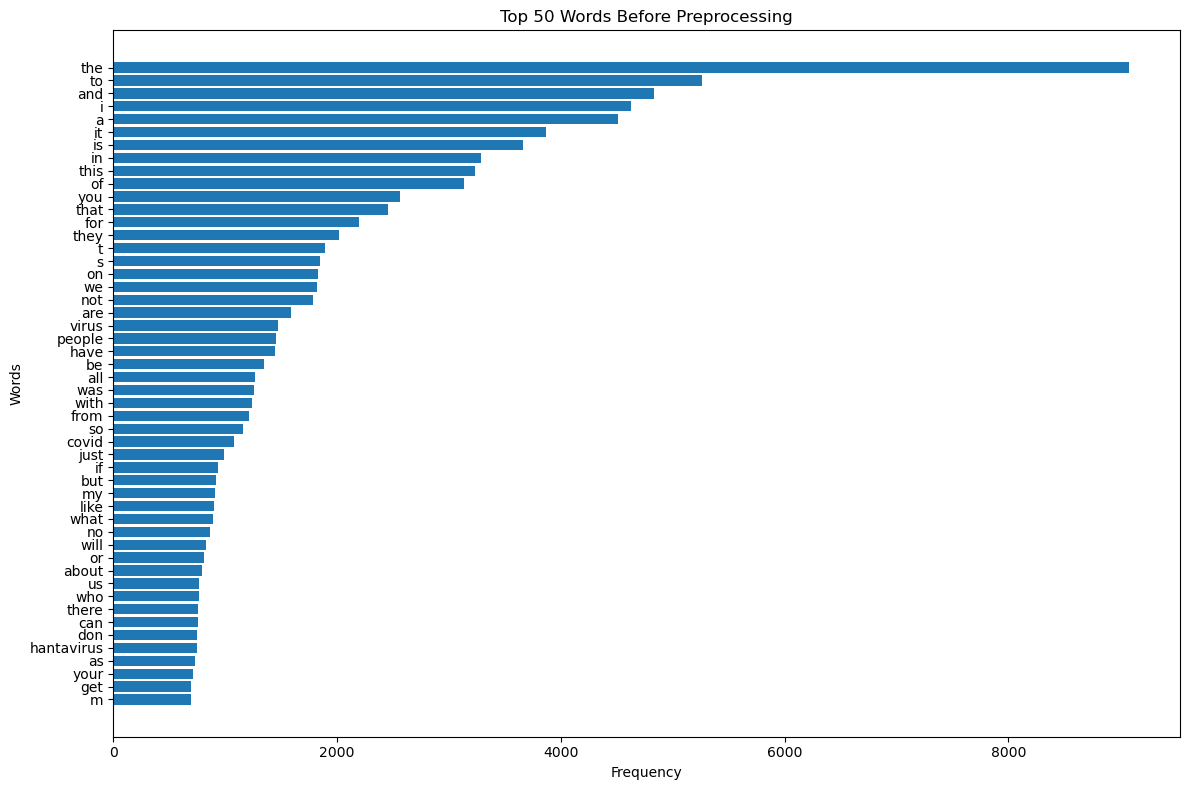

In [18]:
# check top 50 words before preprocessing
all_text = " ".join(comments_df["cleanComment"]).lower()
words = re.findall(r"\b\w+\b", all_text)

word_counts = Counter(words)
top_words = word_counts.most_common(50)

terms = [word for word, count in top_words]
values = [count for word, count in top_words]

plt.figure(figsize=(12, 8))
plt.barh(terms, values)
plt.gca().invert_yaxis()

plt.title("Top 50 Words Before Preprocessing")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.tight_layout()
plt.show()

In [19]:
# check examples of comments detected as non-english
non_english_examples = []

for text in comments_df["cleanComment"]:
    
    # skip empty or very short comments
    if not text or len(text.split()) <= 4:
        continue

    lang, score = langid.classify(text)

    if lang != "en":
        non_english_examples.append((text, lang, score))

    # stop after collecting enough examples
    if len(non_english_examples) >= 20:
        break

for text, lang, score in non_english_examples:
    print(f"[{lang} | {score:.2f}] {text}")

[he | -21.37] 🚨 Global lockdowns ASAP 👆
[it | -30.74] Mamma Mia, here we go again
[vo | -56.79] Let's Go Let's Go Let's Go Mrs Jennifer ❤❤❤❤❤
[la | -49.75] Thanks a bunch, Jennifer ✅💯 Yes, Yes, Yes 👍
[ru | -2323.27] То война, то эпидемия. В следующий раз наверное будет вторжение инопланетян. Не зря же там Трамп постоянно про них упоминает.
[zh | -97.78] Sounds like ya’ll need cats😇🐈🐈‍⬛ Plenty need homes💯♥️
[es | -17.24] gUYS COME TO AUSTRALIA THEREs NO HANTA VIRUS THERe
[pl | -67.38] Gnna get ready fir zombie apocalypse
[km | -175.58] 𝑰 𝒅𝒐𝒏'𝒕 𝒘𝒂𝒏𝒕 𝒐𝒏𝒍𝒊𝒏𝒆 𝒄𝒍𝒂𝒔𝒔𝒆𝒔 😭😭😭😭
[la | -2640.61] Трумп путлер Иран натаньяку си взп орбановцы,Attention, this time is many times worse than during World War II. We stand for good. Supposedly Schmodners — Lenin, Stalin, Putin’s Epsteins, Russians–Muscovites, Trumpists, UEFA, IOC, Mask-like figures, Witkoffs, trash elites, China, MAGA, the Budapest Memorandum, CSTO, UAE, BRICS, SCO, North Korea, Lenin, Trotsky, Stalin, Putin, Hungary–fascism out of the Euro

In [20]:
# helper function to check if text is english
def is_english(text):
    lang, _ = langid.classify(text)
    return lang == "en"

# filter to english comments only
comments_df["word_count"] = comments_df["cleanComment"].str.split().str.len()

comments_df["is_english"] = comments_df["cleanComment"].apply(
    lambda text: is_english(text) if len(text.split()) > 3 else False
)

english_comments_df = comments_df[comments_df["is_english"]].copy()

print("Original comments:", len(comments_df))
print("Filtered English comments:", len(english_comments_df))

Original comments: 12042
Filtered English comments: 9668


In [21]:
# preprocessing helper function for keyword analysis
def processText(text, tokenizer, stopwords):
    
    # convert text to lowercase
    text = text.lower()

    # tokenise text
    tokens = tokenizer.tokenize(text)

    # remove whitespace
    tokens = [token.strip() for token in tokens]

    # remove stopwords, digits and non-alphabetic tokens
    processed_tokens = [
        token for token in tokens
        if token not in stopwords
        and not token.isdigit()
        and token.isalpha()
    ]

    return processed_tokens

In [22]:
# create tokenizer
tweetTokeniser = nltk.tokenize.TweetTokenizer()

# get punctuation and stopwords
punctuation = list(string.punctuation)
standard_stopwords = nltk.corpus.stopwords.words("english")

# add custom stopwords after inspecting common words
custom_stopwords = [
    "video", "like", "just", "get", "people",
    "one", "us", "would", "thank", "know", "go", "going", "got"
]

# combine all stopwords
all_stopwords = set(standard_stopwords + punctuation + ["via"] + custom_stopwords)

In [23]:
# apply preprocessing to english comments
english_comments_df["tokens"] = english_comments_df["cleanComment"].apply(
    lambda text: processText(text, tweetTokeniser, all_stopwords)
)

# flatten all tokens for term frequency analysis
comments_tokens = []

for tokens in english_comments_df["tokens"]:
    comments_tokens.extend(tokens)

commentTermFreqCounter = Counter(comments_tokens)

print("Total tokens after preprocessing:", len(comments_tokens))
print("Unique tokens after preprocessing:", len(commentTermFreqCounter))

Total tokens after preprocessing: 99601
Unique tokens after preprocessing: 12293


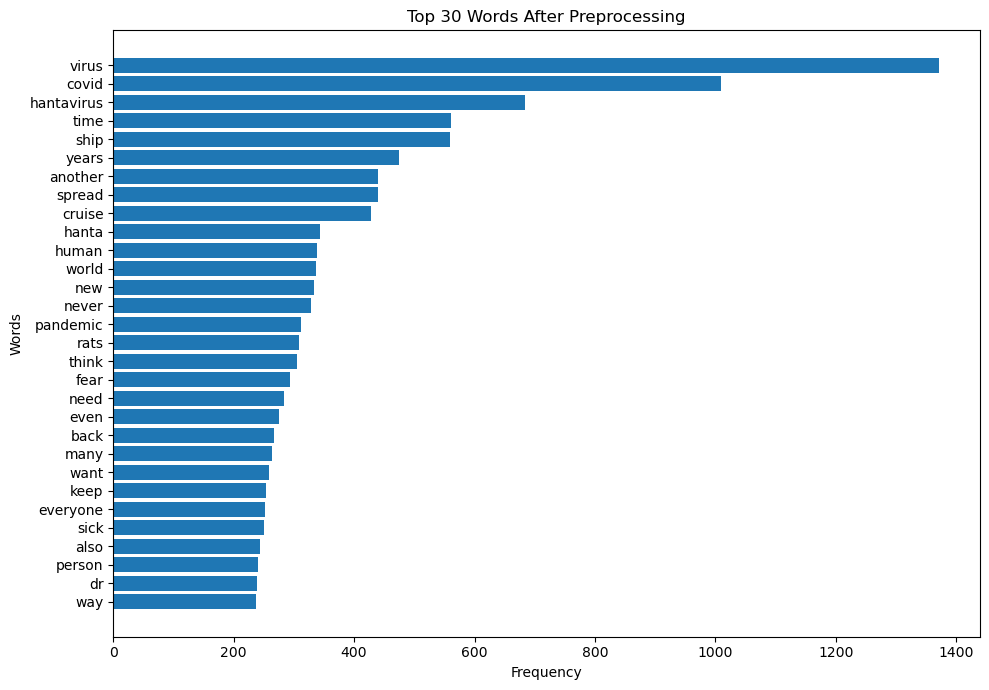

In [24]:
# show top words after preprocessing
top_processed_words = commentTermFreqCounter.most_common(30)

terms = [word for word, count in top_processed_words]
values = [count for word, count in top_processed_words]

plt.figure(figsize=(10, 7))
plt.barh(terms, values)
plt.gca().invert_yaxis()

plt.title("Top 30 Words After Preprocessing")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.tight_layout()
plt.show()

## 4. Term Frequency and Bigram Analysis

This section examines the most common words and word pairs in the YouTube dataset. Title term frequency is used to understand how videos frame the Hantavirus discussion, while comment term frequency and bigrams are used to identify common public concerns, themes and repeated phrases. This supports the later sentiment analysis by showing what topics users are reacting to.

### 4.1 Term Frequency

In [25]:
# count term frequencies in video titles
titleTermFreqCounter = Counter()

for title in videos_df["title"]:
    tokens = processText(
        text=title,
        tokenizer=tweetTokeniser,
        stopwords=all_stopwords
    )
    titleTermFreqCounter.update(tokens)

# print top title terms
print("Top 20 most frequent terms in video titles:\n")
for term, count in titleTermFreqCounter.most_common(20):
    print(f"{term}: {count}")

Top 20 most frequent terms in video titles:

hantavirus: 81
cruise: 27
ship: 27
outbreak: 20
news: 12
explains: 9
symptoms: 9
health: 8
update: 7
explained: 7
deadly: 6
dr: 6
expert: 6
virus: 5
positive: 5
officials: 4
passengers: 4
tests: 4
risk: 4
syndrome: 4


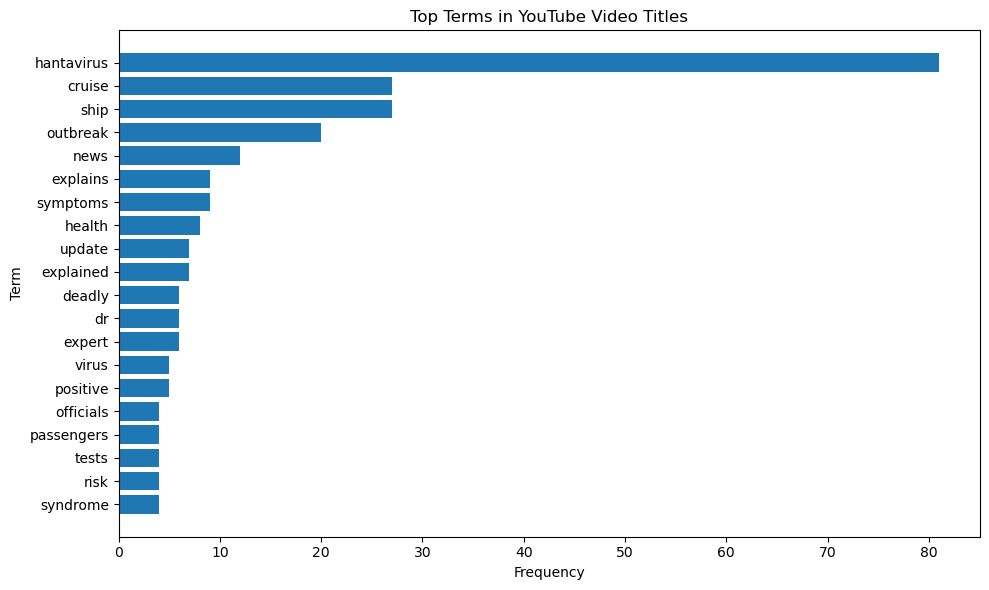

In [26]:
# plot top title terms
top_title_terms = titleTermFreqCounter.most_common(20)

terms = [term for term, count in top_title_terms]
values = [count for term, count in top_title_terms]

plt.figure(figsize=(10, 6))
plt.barh(terms, values)
plt.gca().invert_yaxis()

plt.title("Top Terms in YouTube Video Titles")
plt.xlabel("Frequency")
plt.ylabel("Term")

plt.tight_layout()
plt.show()

In [27]:
# count term frequencies in english comments
commentTermFreqCounter = Counter()

for tokens in english_comments_df["tokens"]:
    commentTermFreqCounter.update(tokens)

# print top comment terms
print("Top 20 most frequent terms in comments:\n")
for term, count in commentTermFreqCounter.most_common(20):
    print(f"{term}: {count}")

Top 20 most frequent terms in comments:

virus: 1371
covid: 1010
hantavirus: 684
time: 561
ship: 560
years: 475
another: 440
spread: 440
cruise: 428
hanta: 344
human: 338
world: 336
new: 333
never: 329
pandemic: 311
rats: 308
think: 305
fear: 293
need: 284
even: 275


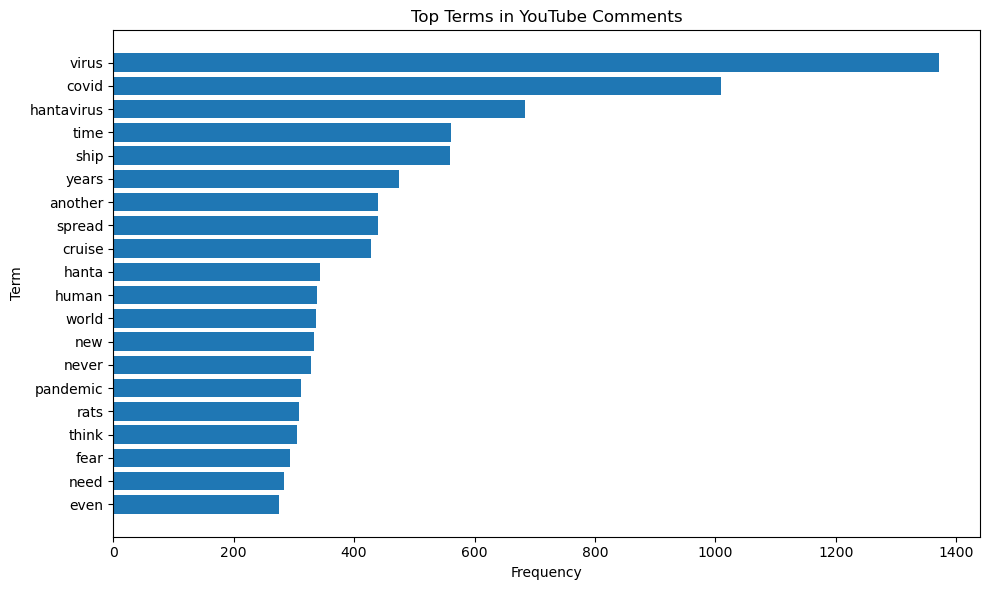

In [28]:
# plot top comment terms
top_comment_terms = commentTermFreqCounter.most_common(20)

terms = [term for term, count in top_comment_terms]
values = [count for term, count in top_comment_terms]

plt.figure(figsize=(10, 6))
plt.barh(terms, values)
plt.gca().invert_yaxis()

plt.title("Top Terms in YouTube Comments")
plt.xlabel("Frequency")
plt.ylabel("Term")

plt.tight_layout()
plt.show()

### 4.2 Bigram analysis

In [29]:
from sklearn.feature_extraction.text import CountVectorizer

# join preprocessed tokens back into strings for vectorizer
cleaned_comments = english_comments_df["tokens"].apply(lambda tokens: " ".join(tokens))

# create bigram model
vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    min_df=3
)

# fit and transform comments into bigram counts
X = vectorizer.fit_transform(cleaned_comments)

# extract bigram terms and counts
bigrams = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1

# pair bigrams with counts and sort
bigram_counts = list(zip(bigrams, counts))
bigram_counts = sorted(bigram_counts, key=lambda x: x[1], reverse=True)

# print top 20 bigrams
print("Top 20 bigrams in comments:\n")
for term, count in bigram_counts[:20]:
    print(f"{term}: {count}")

Top 20 bigrams in comments:

cruise ship: 196
hanta virus: 134
human human: 123
years ago: 119
fear mongering: 74
wash hands: 73
incubation period: 67
cruise ships: 66
bill gates: 62
years old: 58
another pandemic: 55
person person: 53
stay home: 51
dr campbell: 41
please keep: 39
south africa: 39
immune system: 38
new virus: 37
united states: 37
wear mask: 37


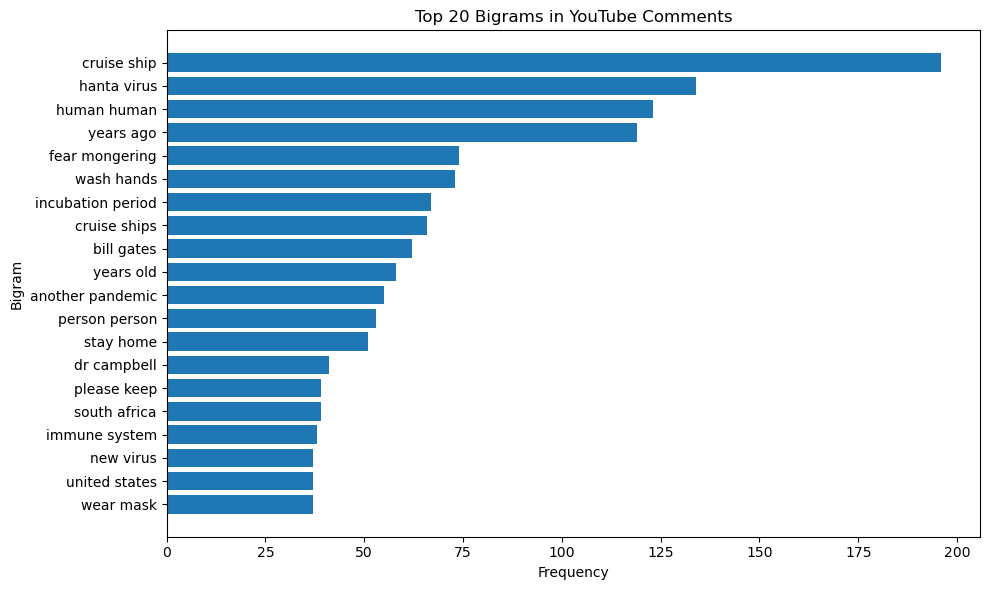

In [30]:
# plot top bigrams
top_bigrams = bigram_counts[:20]

terms = [term for term, count in top_bigrams]
values = [count for term, count in top_bigrams]

plt.figure(figsize=(10, 6))
plt.barh(terms, values)
plt.gca().invert_yaxis()

plt.title("Top 20 Bigrams in YouTube Comments")
plt.xlabel("Frequency")
plt.ylabel("Bigram")

plt.tight_layout()
plt.show()

## 5. VADER Sentiment Analysis

This section uses VADER sentiment analysis to classify YouTube comments as positive, neutral or negative. VADER is suitable for social media text because it is designed to handle short informal comments, punctuation and common emotional language.

The analysis uses the lightly cleaned full comment text rather than the heavily tokenised version, because VADER performs better when sentence context is preserved.

In [31]:
# imports for sentiment analysis
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/hazelkok/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [32]:
# create vader sentiment analyser
sentAnalyser = SentimentIntensityAnalyzer()

In [33]:
# helper function to classify vader compound scores
def classify_vader_sentiment(score):
    if score > 0.05:
        return "positive"
    elif score < -0.05:
        return "negative"
    else:
        return "neutral"

In [34]:
# apply vader sentiment analysis to cleaned comments
english_comments_df["vader_scores"] = english_comments_df["cleanComment"].apply(
    lambda text: sentAnalyser.polarity_scores(text)
)

# extract vader scores into separate columns
english_comments_df["compound"] = english_comments_df["vader_scores"].apply(lambda score: score["compound"])
english_comments_df["vader_positive"] = english_comments_df["vader_scores"].apply(lambda score: score["pos"])
english_comments_df["vader_neutral"] = english_comments_df["vader_scores"].apply(lambda score: score["neu"])
english_comments_df["vader_negative"] = english_comments_df["vader_scores"].apply(lambda score: score["neg"])

# create sentiment label
english_comments_df["vader_label"] = english_comments_df["compound"].apply(classify_vader_sentiment)

english_comments_df[["cleanComment", "compound", "vader_label"]].head()

,cleanComment,compound,vader_label
0,What happened to the CDC staff that were suppo...,-0.6486,negative
1,"Hopefully that virus, will cease from spreading.",0.4019,positive
2,This virus is a minor problem compared to the ...,-0.4019,negative
3,I wonder what these criminals are up to now.,-0.5719,negative
4,When you stop reporting fake health concerns t...,-0.7579,negative


In [35]:
# count vader sentiment labels
vader_counts = english_comments_df["vader_label"].value_counts()

print("VADER sentiment counts:")
print(vader_counts)

# calculate percentages
vader_percentages = english_comments_df["vader_label"].value_counts(normalize=True) * 100

print("\nVADER sentiment percentages:")
print(vader_percentages.round(2))

VADER sentiment counts:
vader_label
negative    3411
positive    3302
neutral     2955
Name: count, dtype: int64

VADER sentiment percentages:
vader_label
negative    35.28
positive    34.15
neutral     30.56
Name: proportion, dtype: float64


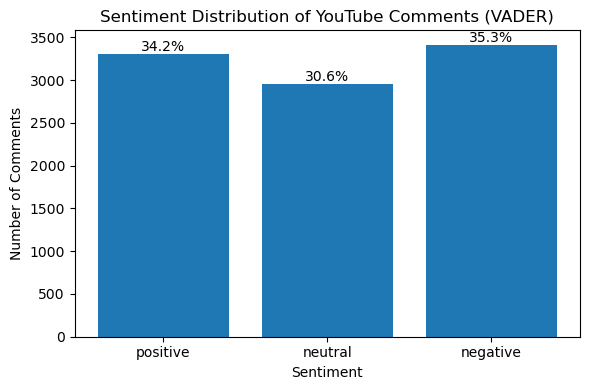

In [36]:
# plot vader sentiment distribution
labels = ["positive", "neutral", "negative"]

values = [vader_counts.get(label, 0) for label in labels]
percentages = [vader_percentages.get(label, 0) for label in labels]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values)

plt.title("Sentiment Distribution of YouTube Comments (VADER)")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")

# add percentage labels above bars
for i, bar in enumerate(bars):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentages[i]:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

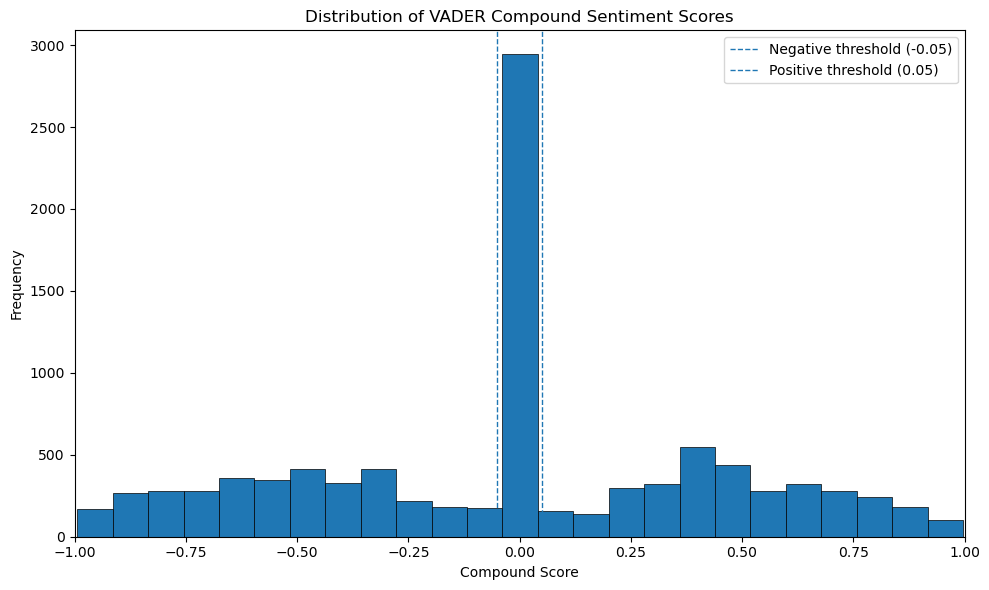

In [37]:
# plot distribution of vader compound scores
plt.figure(figsize=(10, 6))

plt.hist(
    english_comments_df["compound"],
    bins=25,
    edgecolor="black",
    linewidth=0.5
)

plt.axvline(-0.05, linestyle="--", linewidth=1, label="Negative threshold (-0.05)")
plt.axvline(0.05, linestyle="--", linewidth=1, label="Positive threshold (0.05)")

plt.title("Distribution of VADER Compound Sentiment Scores")
plt.xlabel("Compound Score")
plt.ylabel("Frequency")
plt.xlim(-1, 1)
plt.legend()

plt.tight_layout()
plt.show()

In [38]:
# show most positive comments
english_comments_df.sort_values(
    "compound", ascending=False
)[["cleanComment", "compound", "vader_label"]].head(10)

,cleanComment,compound,vader_label
1183,UK's national soil database released as open-a...,0.9966,positive
7934,"Hi Dr. William , have a blessed day ahead ! th...",0.9942,positive
1323,Hey ya’ll!! I’m writing from Savannah Georgia ...,0.9917,positive
1854,"Dear Heavenly Father, as Your daughter I stand...",0.9909,positive
7719,"Hi Dr. William , have a blessed day ahead ! I ...",0.9907,positive
4643,I do not care how wealthy or powerful certain ...,0.9896,positive
4709,They will never let us live in freedom and pea...,0.9825,positive
9242,Thanks mister chubbyemu for all your awesome c...,0.9809,positive
7940,I'm in that situation almost every day mouse d...,0.9794,positive
9066,I hear you telling me not to worry but I have ...,0.9792,positive


In [39]:
# show most negative comments
english_comments_df.sort_values(
    "compound", ascending=True
)[["cleanComment", "compound", "vader_label"]].head(10)

,cleanComment,compound,vader_label
1988,"Personally, I'm so tired of everything being l...",-0.9945,negative
4657,THE BRITISH AND THE USA SPREAD THE SPANISH FLU...,-0.9943,negative
8824,Igor Bogdanoff speaking to project earth exper...,-0.9935,negative
8331,"The Same Old Scam, Repackaged With a New Name ...",-0.9927,negative
6239,"Guys, understand they visited a LANDFILL to wa...",-0.9920,negative
10096,"No offense but Dr. Dray is a dermatologist, no...",-0.9894,negative
11130,the #covid jab and distancing were a lot of bs...,-0.9887,negative
7050,Well when people continued to get boost vaccin...,-0.9849,negative
9147,It’s understandable to feel scared when videos...,-0.9848,negative
466,It’s understandable to feel scared when videos...,-0.9848,negative


## 6. Sentiment by Video Type

This section compares YouTube comment sentiment across different types of videos. The video source type was classified using the video title and channel name, with categories including news media, medical/expert, political commentary and general/trending content.

This comparison helps examine whether public sentiment differs depending on the type of content users are responding to.

### 6.1 Classifying YouTube Videos by Source Type

In [40]:
videos_for_classification = videos_df[videos_df["commentsFetched"] >= 20].copy()

videos_for_classification[[
    "videoId", "title", "channelTitle", "commentsFetched", "url"
]].sort_values("commentsFetched", ascending=False)

,videoId,title,channelTitle,commentsFetched,url
39,3kke7qAGWFQ,How to Survive a Hantavirus,UC San Francisco (UCSF),1256,https://www.youtube.com/watch?v=3kke7qAGWFQ
40,lUGCswwHmls,Hantavirus risk,Dr. John Campbell,1188,https://www.youtube.com/watch?v=lUGCswwHmls
53,R5PqcngCWp4,Hantavirus Situation Is Insane,Chubbyemu,1185,https://www.youtube.com/watch?v=R5PqcngCWp4
37,yZTMkyq6fyY,What is hantavirus and how is it spread? | BBC...,BBC News,1063,https://www.youtube.com/watch?v=yZTMkyq6fyY
46,mFc5kylM8UM,Hantavirus Pulmonary Syndrome Explained | Symp...,Bio Bites,806,https://www.youtube.com/watch?v=mFc5kylM8UM
25,c6kTY3ycyBc,Hantavirus News: The Cruise Ship &amp; Is it R...,Annie Elise,781,https://www.youtube.com/watch?v=c6kTY3ycyBc
32,Wzwf3phTHN0,Hantavirus UPDATE: Health Officials WARN Of Da...,Snyder Reports,422,https://www.youtube.com/watch?v=Wzwf3phTHN0
85,hjAdfGIEfjg,"La crise de l&#39;hantavirus, une gigantesque ...",FRANCE 24,382,https://www.youtube.com/watch?v=hjAdfGIEfjg
70,a7_EdnzJHUE,Official who leads public outreach on Hantavir...,Aaron Parnas,342,https://www.youtube.com/watch?v=a7_EdnzJHUE
11,wf6JWXltPhw,Why health officials expect hantavirus cases t...,CBS News,336,https://www.youtube.com/watch?v=wf6JWXltPhw


Videos with fewer than 20 collected comments were excluded from the source-type comparison because very small comment samples may not provide reliable sentiment patterns. The remaining videos were manually reviewed and classified into broad source types based on the channel and video framing.

In [41]:
def classify_source_type(channel_title, title):
    channel_title = str(channel_title).lower()
    title = str(title).lower()
    combined = channel_title + " " + title

    medical_keywords = [
        "dr", "doctor", "m.d", "md", "medical", "medicine", "health",
        "clinic", "hospital", "physician", "pediatrician", "dermatologist",
        "expert", "science", "university", "uc san francisco", "ucsf",
        "physicians committee", "museum of science"
    ]

    news_keywords = [
        "news", "bbc", "cnn", "abc", "cbs", "global news", "france 24",
        "channel 4", "usa today", "time", "wall street journal",
        "new york times", "al jazeera", "vox", "reuters", "m6 info"
    ]

    political_keywords = [
        "trump", "administration", "political", "politics",
        "aaron parnas", "zeteo", "daily show"
    ]

    if any(word in combined for word in political_keywords):
        return "political_commentary"
    elif any(word in combined for word in news_keywords):
        return "news_media"
    elif any(word in combined for word in medical_keywords):
        return "medical_expert"
    else:
        return "general_trending"

In [42]:
videos_df["channel_type"] = videos_df.apply(
    lambda row: classify_source_type(row["channelTitle"], row["title"]),
    axis=1
)

In [43]:
videos_df[[
    "videoId", "title", "channelTitle", "commentsFetched", "channel_type", "url"
]].sort_values("commentsFetched", ascending=False).head(60)

,videoId,title,channelTitle,commentsFetched,channel_type,url
39,3kke7qAGWFQ,How to Survive a Hantavirus,UC San Francisco (UCSF),1256,medical_expert,https://www.youtube.com/watch?v=3kke7qAGWFQ
40,lUGCswwHmls,Hantavirus risk,Dr. John Campbell,1188,medical_expert,https://www.youtube.com/watch?v=lUGCswwHmls
53,R5PqcngCWp4,Hantavirus Situation Is Insane,Chubbyemu,1185,general_trending,https://www.youtube.com/watch?v=R5PqcngCWp4
37,yZTMkyq6fyY,What is hantavirus and how is it spread? | BBC...,BBC News,1063,news_media,https://www.youtube.com/watch?v=yZTMkyq6fyY
46,mFc5kylM8UM,Hantavirus Pulmonary Syndrome Explained | Symp...,Bio Bites,806,medical_expert,https://www.youtube.com/watch?v=mFc5kylM8UM
25,c6kTY3ycyBc,Hantavirus News: The Cruise Ship &amp; Is it R...,Annie Elise,781,news_media,https://www.youtube.com/watch?v=c6kTY3ycyBc
32,Wzwf3phTHN0,Hantavirus UPDATE: Health Officials WARN Of Da...,Snyder Reports,422,medical_expert,https://www.youtube.com/watch?v=Wzwf3phTHN0
85,hjAdfGIEfjg,"La crise de l&#39;hantavirus, une gigantesque ...",FRANCE 24,382,news_media,https://www.youtube.com/watch?v=hjAdfGIEfjg
70,a7_EdnzJHUE,Official who leads public outreach on Hantavir...,Aaron Parnas,342,political_commentary,https://www.youtube.com/watch?v=a7_EdnzJHUE
11,wf6JWXltPhw,Why health officials expect hantavirus cases t...,CBS News,336,news_media,https://www.youtube.com/watch?v=wf6JWXltPhw


### 6.2 Video type distribution

In [44]:
# check number of videos by channel type
videos_df["channel_type"].value_counts()

channel_type
news_media              48
medical_expert          19
general_trending        16
political_commentary     3
Name: count, dtype: int64

In [45]:
# check number of fetched comments by channel type
comments_by_type = videos_df.groupby("channel_type")["commentsFetched"].sum().sort_values(ascending=False)

comments_by_type

channel_type
news_media              5223
medical_expert          4421
general_trending        1880
political_commentary     518
Name: commentsFetched, dtype: int64

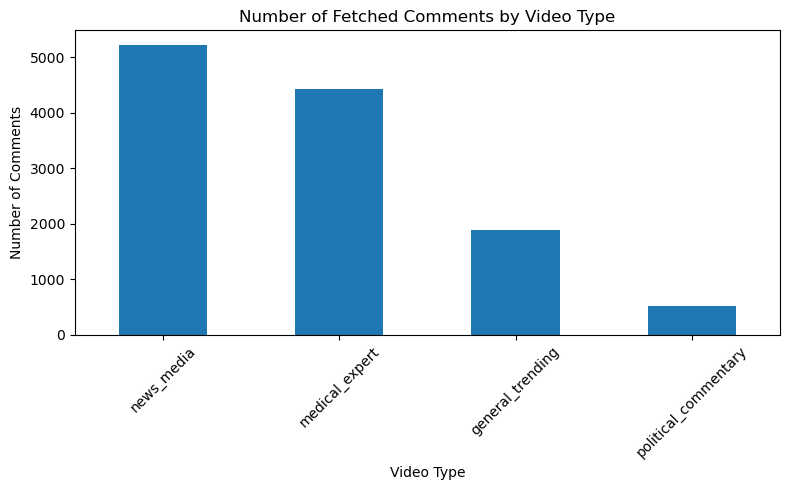

In [46]:
# plot number of fetched comments by channel type
plt.figure(figsize=(8, 5))
comments_by_type.plot(kind="bar")

plt.title("Number of Fetched Comments by Video Type")
plt.xlabel("Video Type")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The video type distribution shows that the dataset is mainly made up of news media and medical/expert content. News media videos contributed the largest number of videos and comments, while medical/expert videos also generated a large number of comments despite having fewer videos. This makes the comparison between news media and medical/expert content useful for examining whether public sentiment differs depending on the source and framing of the video.

Political commentary videos were less common in the dataset, so results for this category should be interpreted carefully.

### 6.3 Sentiment Distribution and Average Sentiment by Video Type

In [47]:
# merge video type into the sentiment/comment dataframe
english_comments_df = english_comments_df.merge(
    videos_df[["videoId", "channel_type"]],
    on="videoId",
    how="left"
)

# check merge worked
english_comments_df[[
    "videoId", "channelTitle", "channel_type", "vader_label", "compound"
]].head()

,videoId,channelTitle,channel_type,vader_label,compound
0,V07bI_iyMVA,NBC News,news_media,negative,-0.6486
1,V07bI_iyMVA,NBC News,news_media,positive,0.4019
2,KpZN0OA0GNc,SABC News,news_media,negative,-0.4019
3,KpZN0OA0GNc,SABC News,news_media,negative,-0.5719
4,KpZN0OA0GNc,SABC News,news_media,negative,-0.7579


In [48]:
english_comments_df["channel_type"].value_counts(dropna=False)

channel_type
news_media              4062
medical_expert          3594
general_trending        1598
political_commentary     414
Name: count, dtype: int64

In [49]:
# create sentiment percentage table by channel type
sentiment_percent_by_type = pd.crosstab(
    english_comments_df["channel_type"],
    english_comments_df["vader_label"],
    normalize="index"
) * 100

sentiment_percent_by_type.round(2)

vader_label,negative,neutral,positive
channel_type,,,
general_trending,40.11,25.97,33.92
medical_expert,31.19,33.42,35.39
news_media,36.63,29.89,33.48
political_commentary,38.89,30.19,30.92


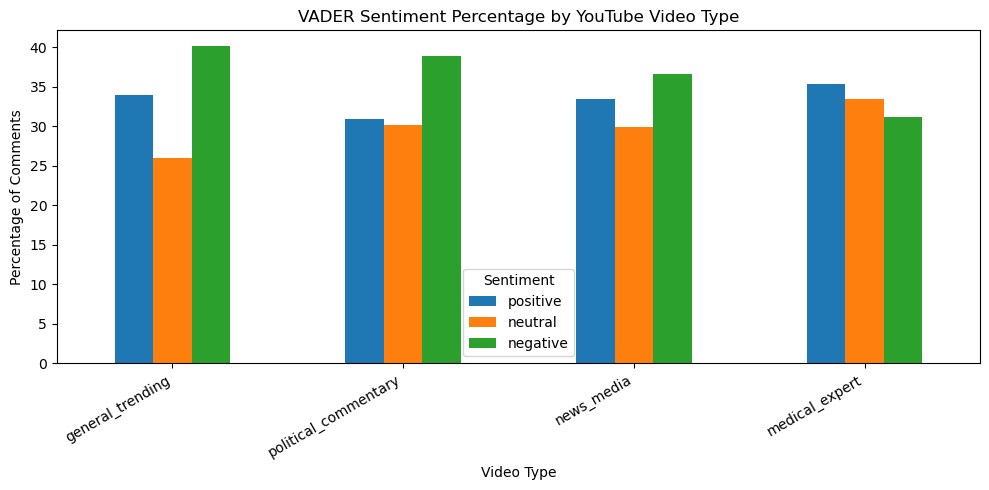

In [50]:
# set sentiment column order
sentiment_order = ["positive", "neutral", "negative"]

# make sure all sentiment columns exist
for label in sentiment_order:
    if label not in sentiment_percent_by_type.columns:
        sentiment_percent_by_type[label] = 0

# reorder columns
sentiment_percent_by_type = sentiment_percent_by_type[sentiment_order]

# sort video types by negative percentage
sentiment_percent_by_type = sentiment_percent_by_type.sort_values("negative", ascending=False)

# plot grouped bar chart instead of stacked chart
ax = sentiment_percent_by_type.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("VADER Sentiment Percentage by YouTube Video Type")
plt.xlabel("Video Type")
plt.ylabel("Percentage of Comments")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Sentiment")

plt.tight_layout()
plt.show()

In [51]:
# calculate average compound score by channel type
avg_sentiment_by_type = english_comments_df.groupby("channel_type")["compound"].mean().sort_values(ascending=False)

avg_sentiment_by_type

channel_type
medical_expert          0.018730
news_media             -0.031786
general_trending       -0.037493
political_commentary   -0.055610
Name: compound, dtype: float64

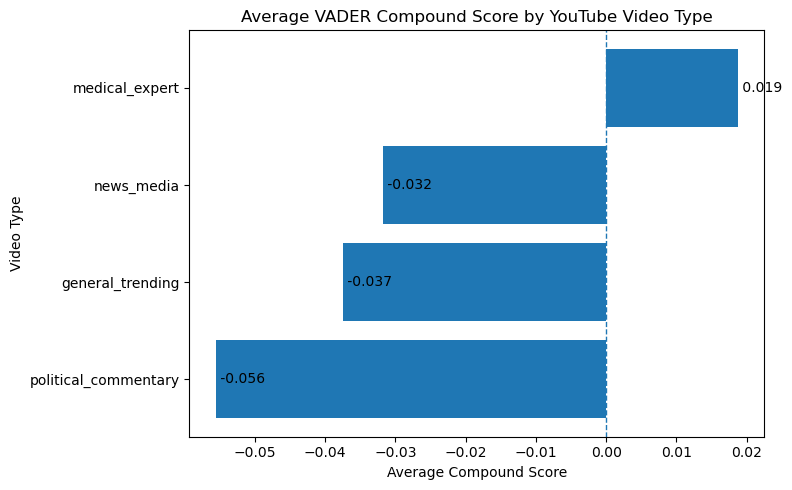

In [52]:
# calculate average compound score by channel type
avg_sentiment_by_type = english_comments_df.groupby("channel_type")["compound"].mean()
avg_sentiment_by_type = avg_sentiment_by_type.sort_values()

# plot horizontal bar chart
plt.figure(figsize=(8, 5))
plt.barh(avg_sentiment_by_type.index, avg_sentiment_by_type.values)

plt.axvline(0, linestyle="--", linewidth=1)

plt.title("Average VADER Compound Score by YouTube Video Type")
plt.xlabel("Average Compound Score")
plt.ylabel("Video Type")

# add score labels
for i, value in enumerate(avg_sentiment_by_type.values):
    plt.text(value, i, f" {value:.3f}", va="center")

plt.tight_layout()
plt.show()

## 7. Export Final Dataset

In [ ]:
# save final youtube analysis datasets
videos_df.to_csv("Data/youtube_videos_final_analysis.csv", index=False)
english_comments_df.to_csv("Data/youtube_comments_final_analysis.csv", index=False)

print("Saved final YouTube analysis datasets.")

Saved final YouTube analysis datasets.


In [ ]:
ata/youtube_videos_final_analysis.csv", index=False)
english_comments_df.to_csv("Data/youtube_comments_final_analysis.csv", index=False)

print("Saved final YouTube analysis datasets.")

## 8. YouTube Topic Modelling

This section uses Latent Dirichlet Allocation (LDA) to identify common discussion themes in YouTube comments. This complements the VADER sentiment analysis by showing what users were discussing, not only whether the comments were positive, neutral or negative.

The topic model was trained on preprocessed English comments, where comments were tokenised and stopwords were removed. The resulting topics were interpreted by examining the most important words and word clouds for each topic.

In [54]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from wordcloud import WordCloud

In [55]:
# prepare preprocessed comments for lda
lPosts = english_comments_df["tokens"].apply(lambda tokens: " ".join(tokens))

# remove empty processed comments
lPosts = lPosts[lPosts.str.strip() != ""]

print("Number of comments used for topic modelling:", len(lPosts))

Number of comments used for topic modelling: 9638


In [56]:
# lda parameters
topicNum = 4
wordNumToDisplay = 10
featureNum = 1500

# vectorise comments
tfVectorizer = CountVectorizer(
    max_df=0.85,
    min_df=5,
    max_features=featureNum,
    stop_words="english"
)

tf = tfVectorizer.fit_transform(lPosts)
tfFeatureNames = tfVectorizer.get_feature_names_out()

print("Document-term matrix shape:", tf.shape)
print("Number of features:", len(tfFeatureNames))

Document-term matrix shape: (9638, 1500)
Number of features: 1500


In [57]:
# fit lda model
ldaModel = LatentDirichletAllocation(
    n_components=topicNum,
    max_iter=10,
    learning_method="online",
    random_state=42
).fit(tf)

In [58]:
# display top words for each topic
def display_topics(model, featureNames, numTopWords):
    for topicId, topicDist in enumerate(model.components_):
        top_words = [
            featureNames[i]
            for i in topicDist.argsort()[:-numTopWords - 1:-1]
        ]

        print(f"Topic {topicId + 1}:")
        print(", ".join(top_words))
        print()

display_topics(ldaModel, tfFeatureNames, wordNumToDisplay)

Topic 1:
years, time, need, sick, let, ago, youtube, viruses, died, trust

Topic 2:
ship, cruise, fear, dr, news, rodents, information, disease, infected, rat

Topic 3:
rats, think, getting, thing, mice, make, god, covid, day, pandemic

Topic 4:
virus, covid, hantavirus, human, hanta, world, spread, new, said, vaccine



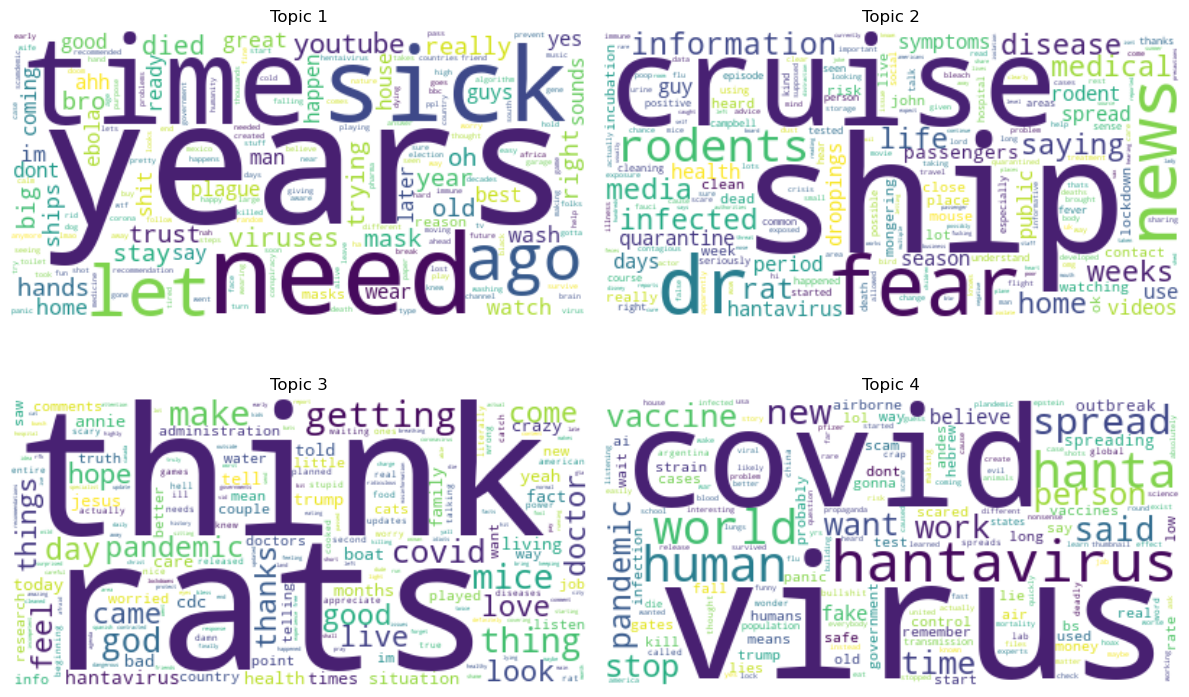

In [59]:
# display word clouds for each topic
def displayWordcloud(model, featureNames):
    normalisedComponents = model.components_ / model.components_.sum(axis=1)[:, np.newaxis]

    plotRowNum = 2
    plotColNum = 2

    plt.figure(figsize=(12, 8))

    for topicId, topicDist in enumerate(normalisedComponents):
        wordProb = {
            featureNames[i]: probability
            for i, probability in enumerate(topicDist)
        }

        wordcloud = WordCloud(
            background_color="white",
            random_state=42
        )

        wordcloud.fit_words(frequencies=wordProb)

        plt.subplot(plotRowNum, plotColNum, topicId + 1)
        plt.title(f"Topic {topicId + 1}")
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

displayWordcloud(ldaModel, tfFeatureNames)

In [60]:
# get topic distribution for each comment
topicDistributions = ldaModel.transform(tf)

# assign each comment to its dominant topic
dominantTopics = topicDistributions.argmax(axis=1)

# count dominant topics
topicCounts = np.bincount(dominantTopics, minlength=topicNum)

# calculate percentages
topicPercentages = topicCounts / topicCounts.sum() * 100

for i, count in enumerate(topicCounts):
    print(f"Topic {i + 1}: {count} comments ({topicPercentages[i]:.2f}%)")

Topic 1: 2756 comments (28.60%)
Topic 2: 2053 comments (21.30%)
Topic 3: 2089 comments (21.67%)
Topic 4: 2740 comments (28.43%)
